# Climate Forecasting as Support for Planting Calendar 

[Historical Weather 1940–2025] in bogor

(Forecasting Model)

[Predicted Weather for year]

(Rule-based / ML Classifier for Planting Suitability per Day) (from literature review)



## 01_EDA

In [76]:
%pip install pandas numpy matplotlib seaborn scipy

2810.91s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [78]:
plt.rcParams.update({
    'figure.dpi': 140,
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 10,
})
sns.set_theme(style='whitegrid', palette='bright')

DATASET_PATH = 'dataset/merged_dataset-1940-2025-bogor.csv'

In [79]:
df_raw = pd.read_csv(DATASET_PATH)
df_raw.head()

,time,weather_code (wmo code),temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),apparent_temperature_max (°C),sunrise (iso8601),sunset (iso8601),...,soil_temperature_0_to_100cm_mean (°C),soil_temperature_0_to_7cm_mean (°C),soil_temperature_28_to_100cm_mean (°C),soil_temperature_7_to_28cm_mean (°C),relative_humidity_2m_mean (%),relative_humidity_2m_max (%),relative_humidity_2m_min (%),surface_pressure_mean (hPa),pressure_msl_mean (hPa),dew_point_2m_mean (°C)
0,1940-01-02,63,23.6,27.5,21.2,25.2,28.4,33.9,1940-01-02T05:41,1940-01-02T18:11,...,25.3,25.2,25.3,25.1,94.0,99,81,983.8,1012.1,22.4
1,1940-01-03,63,23.5,27.9,21.4,25.3,27.5,32.9,1940-01-03T05:42,1940-01-03T18:11,...,25.3,25.1,25.3,25.2,89.0,98,72,983.2,1011.5,21.5
2,1940-01-04,55,23.0,25.6,21.2,24.5,26.4,28.6,1940-01-04T05:42,1940-01-04T18:12,...,25.1,24.1,25.3,24.8,90.0,96,77,982.8,1011.2,21.1
3,1940-01-05,63,23.8,29.1,20.4,23.3,27.4,35.0,1940-01-05T05:43,1940-01-05T18:12,...,25.1,24.8,25.3,24.7,85.0,97,65,982.0,1010.2,21.0
4,1940-01-06,63,23.6,28.6,20.5,23.4,27.9,34.6,1940-01-06T05:43,1940-01-06T18:13,...,25.2,25.2,25.3,25.0,89.0,98,72,981.4,1009.6,21.6


In [ ]:
df_raw['time'] = pd.to_datetime(df_raw['time'])
df_raw['sunrise (iso8601)'] = pd.to_datetime(df_raw['sunrise (iso8601)'])
df_raw['sunset (iso8601)'] = pd.to_datetime(df_raw['sunset (iso8601)'])

df = df_raw.set_index('time').sort_index()

# Map WMO weather codes to descriptions
desc = pd.DataFrame(
    [
        {"Code": "0", "Description": "Cloud development not observed (Clear)"},
        {"Code": "1-3", "Description": "Clouds dissolving or changing"},
        {"Code": "10", "Description": "Mist"},
        {"Code": "45", "Description": "Fog, sky not visible"},
        {"Code": "51", "Description": "Light drizzle"},
        {"Code": "53", "Description": "Moderate drizzle"},
        {"Code": "55", "Description": "Dense drizzle"},
        {"Code": "61", "Description": "Slight rain"},
        {"Code": "63", "Description": "Moderate rain"},
        {"Code": "65", "Description": "Heavy rain"},
        {"Code": "71", "Description": "Slight snow"},
        {"Code": "73", "Description": "Moderate snow"},
        {"Code": "75", "Description": "Heavy snow"},
        {"Code": "80", "Description": "Light rain shower"},
        {"Code": "95", "Description": "Thunderstorm"},
    ]
)


def map_wmo_code(code):
    if pd.isna(code):
        return np.nan

    code = int(code)
    if code == 0:
        return "Cloud development not observed (Clear)"
    if 1 <= code <= 3:
        return "Clouds dissolving or changing"
    if code == 10:
        return "Mist"
    if code == 45:
        return "Fog, sky not visible"
    if code == 51:
        return "Light drizzle"
    if code == 53:
        return "Moderate drizzle"
    if code == 55:
        return "Dense drizzle"
    if code == 61:
        return "Slight rain"
    if code == 63:
        return "Moderate rain"
    if code == 65:
        return "Heavy rain"
    if code == 71:
        return "Slight snow"
    if code == 73:
        return "Moderate snow"
    if code == 75:
        return "Heavy snow"
    if code == 80:
        return "Light rain shower"
    if code == 95:
        return "Thunderstorm"
    return "Other"


df['weather_code (wmo code)'] = df['weather_code (wmo code)'].apply(map_wmo_code)
df['weather_code (wmo code)'] = pd.Categorical(
    df['weather_code (wmo code)'],
    categories=desc['Description'].tolist() + ['Other']
)

df.head()

,weather_code (wmo code),temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),apparent_temperature_max (°C),sunrise (iso8601),sunset (iso8601),daylight_duration (s),...,soil_temperature_0_to_100cm_mean (°C),soil_temperature_0_to_7cm_mean (°C),soil_temperature_28_to_100cm_mean (°C),soil_temperature_7_to_28cm_mean (°C),relative_humidity_2m_mean (%),relative_humidity_2m_max (%),relative_humidity_2m_min (%),surface_pressure_mean (hPa),pressure_msl_mean (hPa),dew_point_2m_mean (°C)
time,,,,,,,,,,,,,,,,,,,,,
1940-01-02,Moderate rain,23.6,27.5,21.2,25.2,28.4,33.9,1940-01-02 05:41:00,1940-01-02 18:11:00,44979.09,...,25.3,25.2,25.3,25.1,94.0,99,81,983.8,1012.1,22.4
1940-01-03,Moderate rain,23.5,27.9,21.4,25.3,27.5,32.9,1940-01-03 05:42:00,1940-01-03 18:11:00,44972.92,...,25.3,25.1,25.3,25.2,89.0,98,72,983.2,1011.5,21.5
1940-01-04,Dense drizzle,23.0,25.6,21.2,24.5,26.4,28.6,1940-01-04 05:42:00,1940-01-04 18:12:00,44966.27,...,25.1,24.1,25.3,24.8,90.0,96,77,982.8,1011.2,21.1
1940-01-05,Moderate rain,23.8,29.1,20.4,23.3,27.4,35.0,1940-01-05 05:43:00,1940-01-05 18:12:00,44959.16,...,25.1,24.8,25.3,24.7,85.0,97,65,982.0,1010.2,21.0
1940-01-06,Moderate rain,23.6,28.6,20.5,23.4,27.9,34.6,1940-01-06 05:43:00,1940-01-06 18:13:00,44951.59,...,25.2,25.2,25.3,25.0,89.0,98,72,981.4,1009.6,21.6


In [85]:
# --- Missing values ---
missing = df.isnull().sum().rename('null_count')
missing_pct = (missing / len(df) * 100).rename('null_pct')
mv_df = pd.concat([missing, missing_pct], axis=1)
print('=== Missing Values')
print(mv_df[mv_df['null_count'] > 0] if mv_df['null_count'].any() else 'No missing values')

# --- Hari hilang ---
full_idx = pd.date_range(df.index.min(), df.index.max(), freq='D')
missing_dates = full_idx.difference(df.index)
print('\n=== Gap Tanggal')
print(f'Days (1940 - 2025) : {len(full_idx)}')
print(f'Days in dataset    : {len(df)}')
print(f'Missing dates      : {len(missing_dates)}')
if len(missing_dates):
    print(missing_dates)
    
# at first, we encounter missing dates from 1959-01-02 to 1959-12-31

=== Missing Values
No missing values

=== Gap Tanggal
Days (1940 - 2025) : 31411
Days in dataset    : 31411
Missing dates      : 0


In [82]:
numeric_df = df.select_dtypes(include=[np.number])
desc = numeric_df.describe().T
desc['skewness'] = numeric_df.apply(lambda c: c.skew())
desc['kurtosis'] = numeric_df.apply(lambda c: c.kurtosis())
desc.round(4)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
temperature_2m_mean (°C),31411.0,24.7805,0.9219,21.600,24.200,24.700,25.300,29.700,0.6396,0.8677
temperature_2m_max (°C),31411.0,29.1366,1.5329,23.200,28.300,29.100,29.900,37.500,0.4988,2.1531
temperature_2m_min (°C),31411.0,21.4001,1.0153,15.100,20.800,21.500,22.100,25.000,-0.4723,1.1806
apparent_temperature_min (°C),31411.0,25.0121,1.5013,15.400,24.200,25.200,26.000,29.700,-0.6976,1.3867
apparent_temperature_mean (°C),31411.0,29.1549,1.0507,23.300,28.500,29.200,29.900,33.400,-0.0837,0.2314
apparent_temperature_max (°C),31411.0,34.5765,1.8179,26.200,33.600,34.700,35.800,41.300,-0.5217,0.7054
daylight_duration (s),31411.0,43598.5270,950.3370,42264.360,42668.800,43562.030,44524.100,45014.580,0.0639,-1.4508
sunshine_duration (s),31411.0,35163.0838,8839.2491,0.000,31926.995,38552.410,41431.825,44086.180,-1.7972,3.1936
precipitation_sum (mm),31411.0,7.1409,7.9396,0.000,1.300,4.800,10.600,127.400,2.5885,15.5965
rain_sum (mm),31411.0,7.1409,7.9396,0.000,1.300,4.800,10.600,127.400,2.5885,15.5965


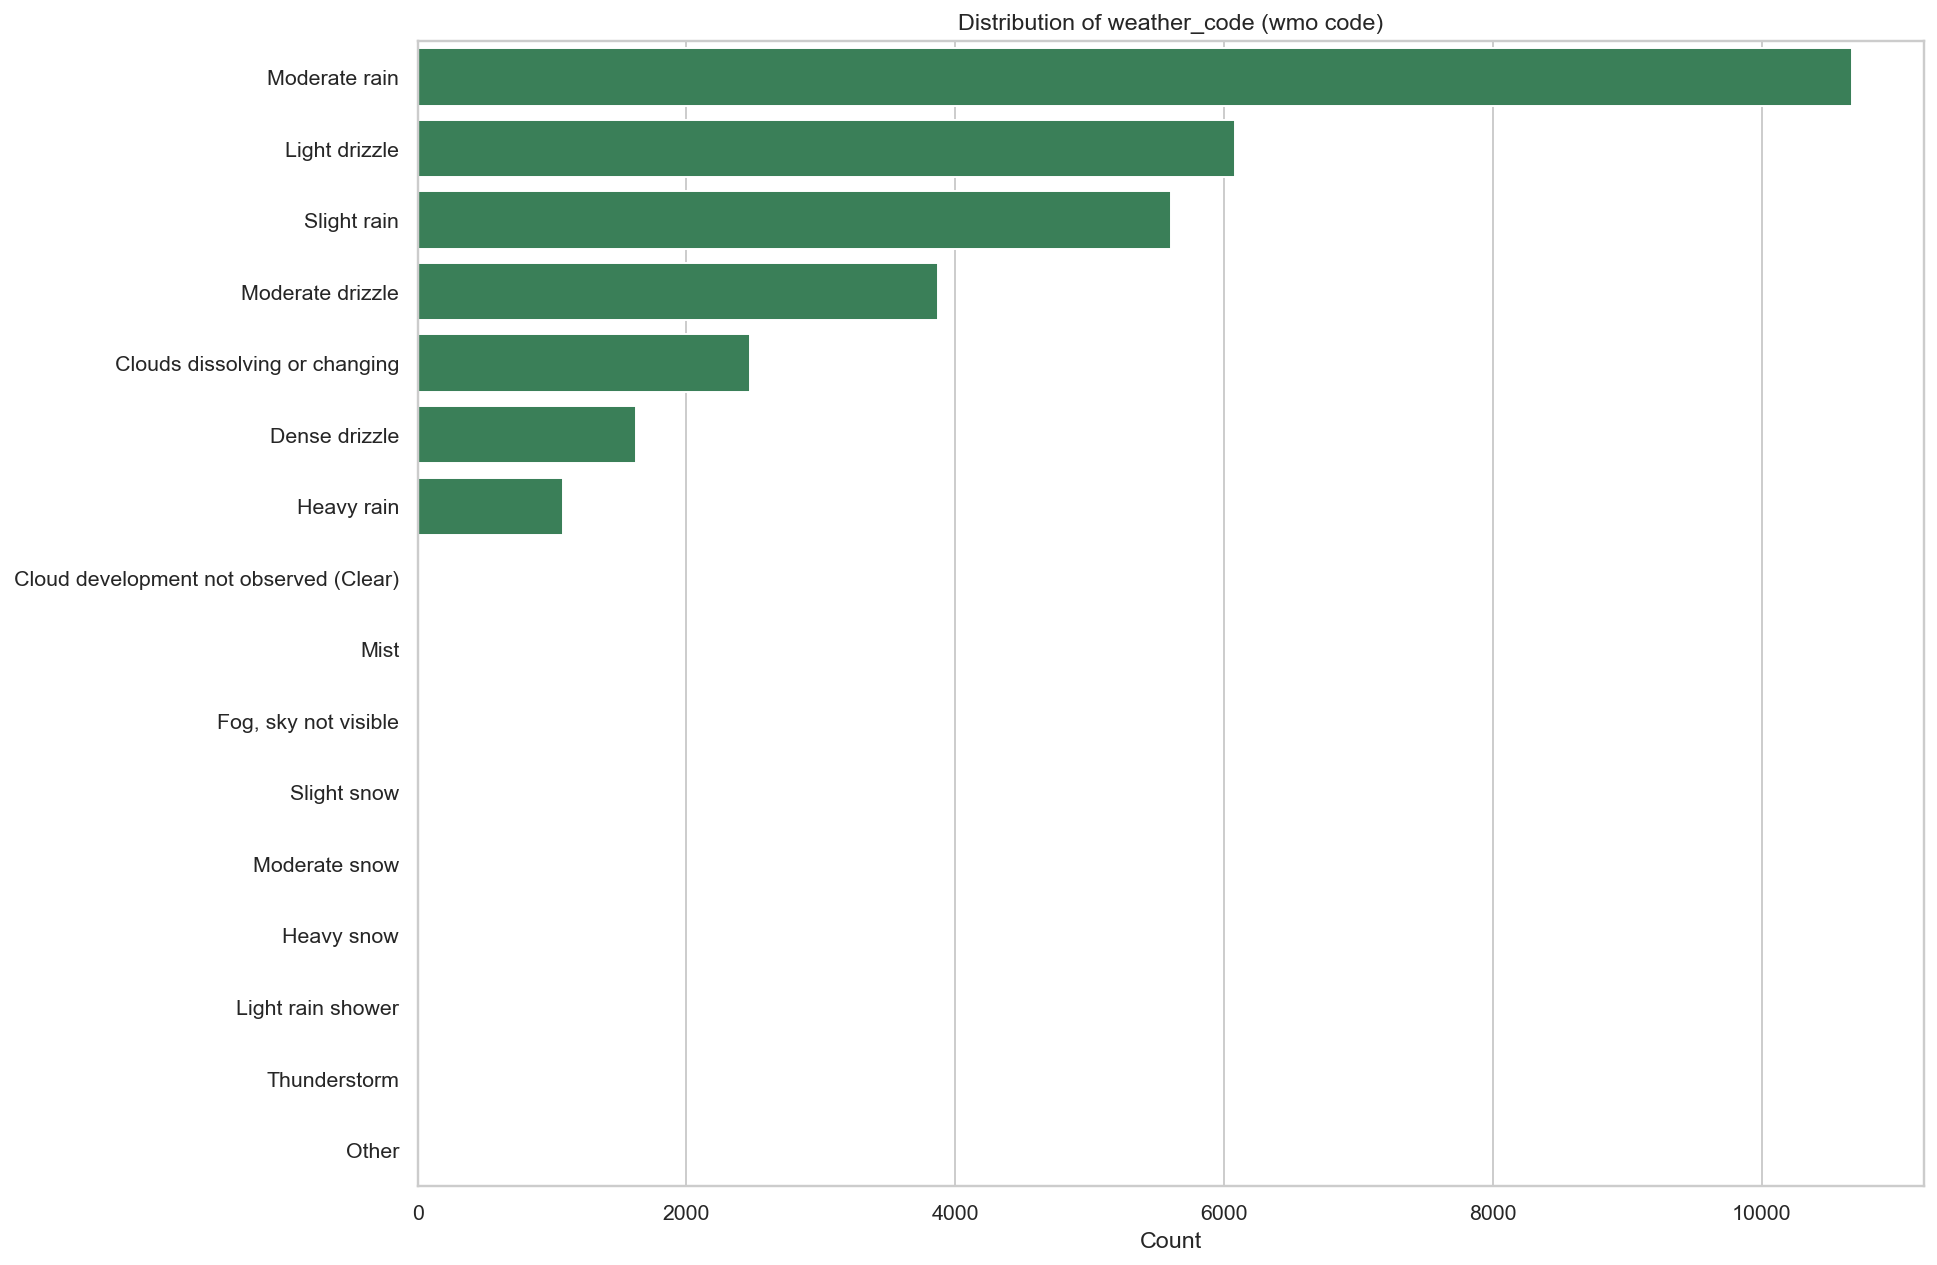

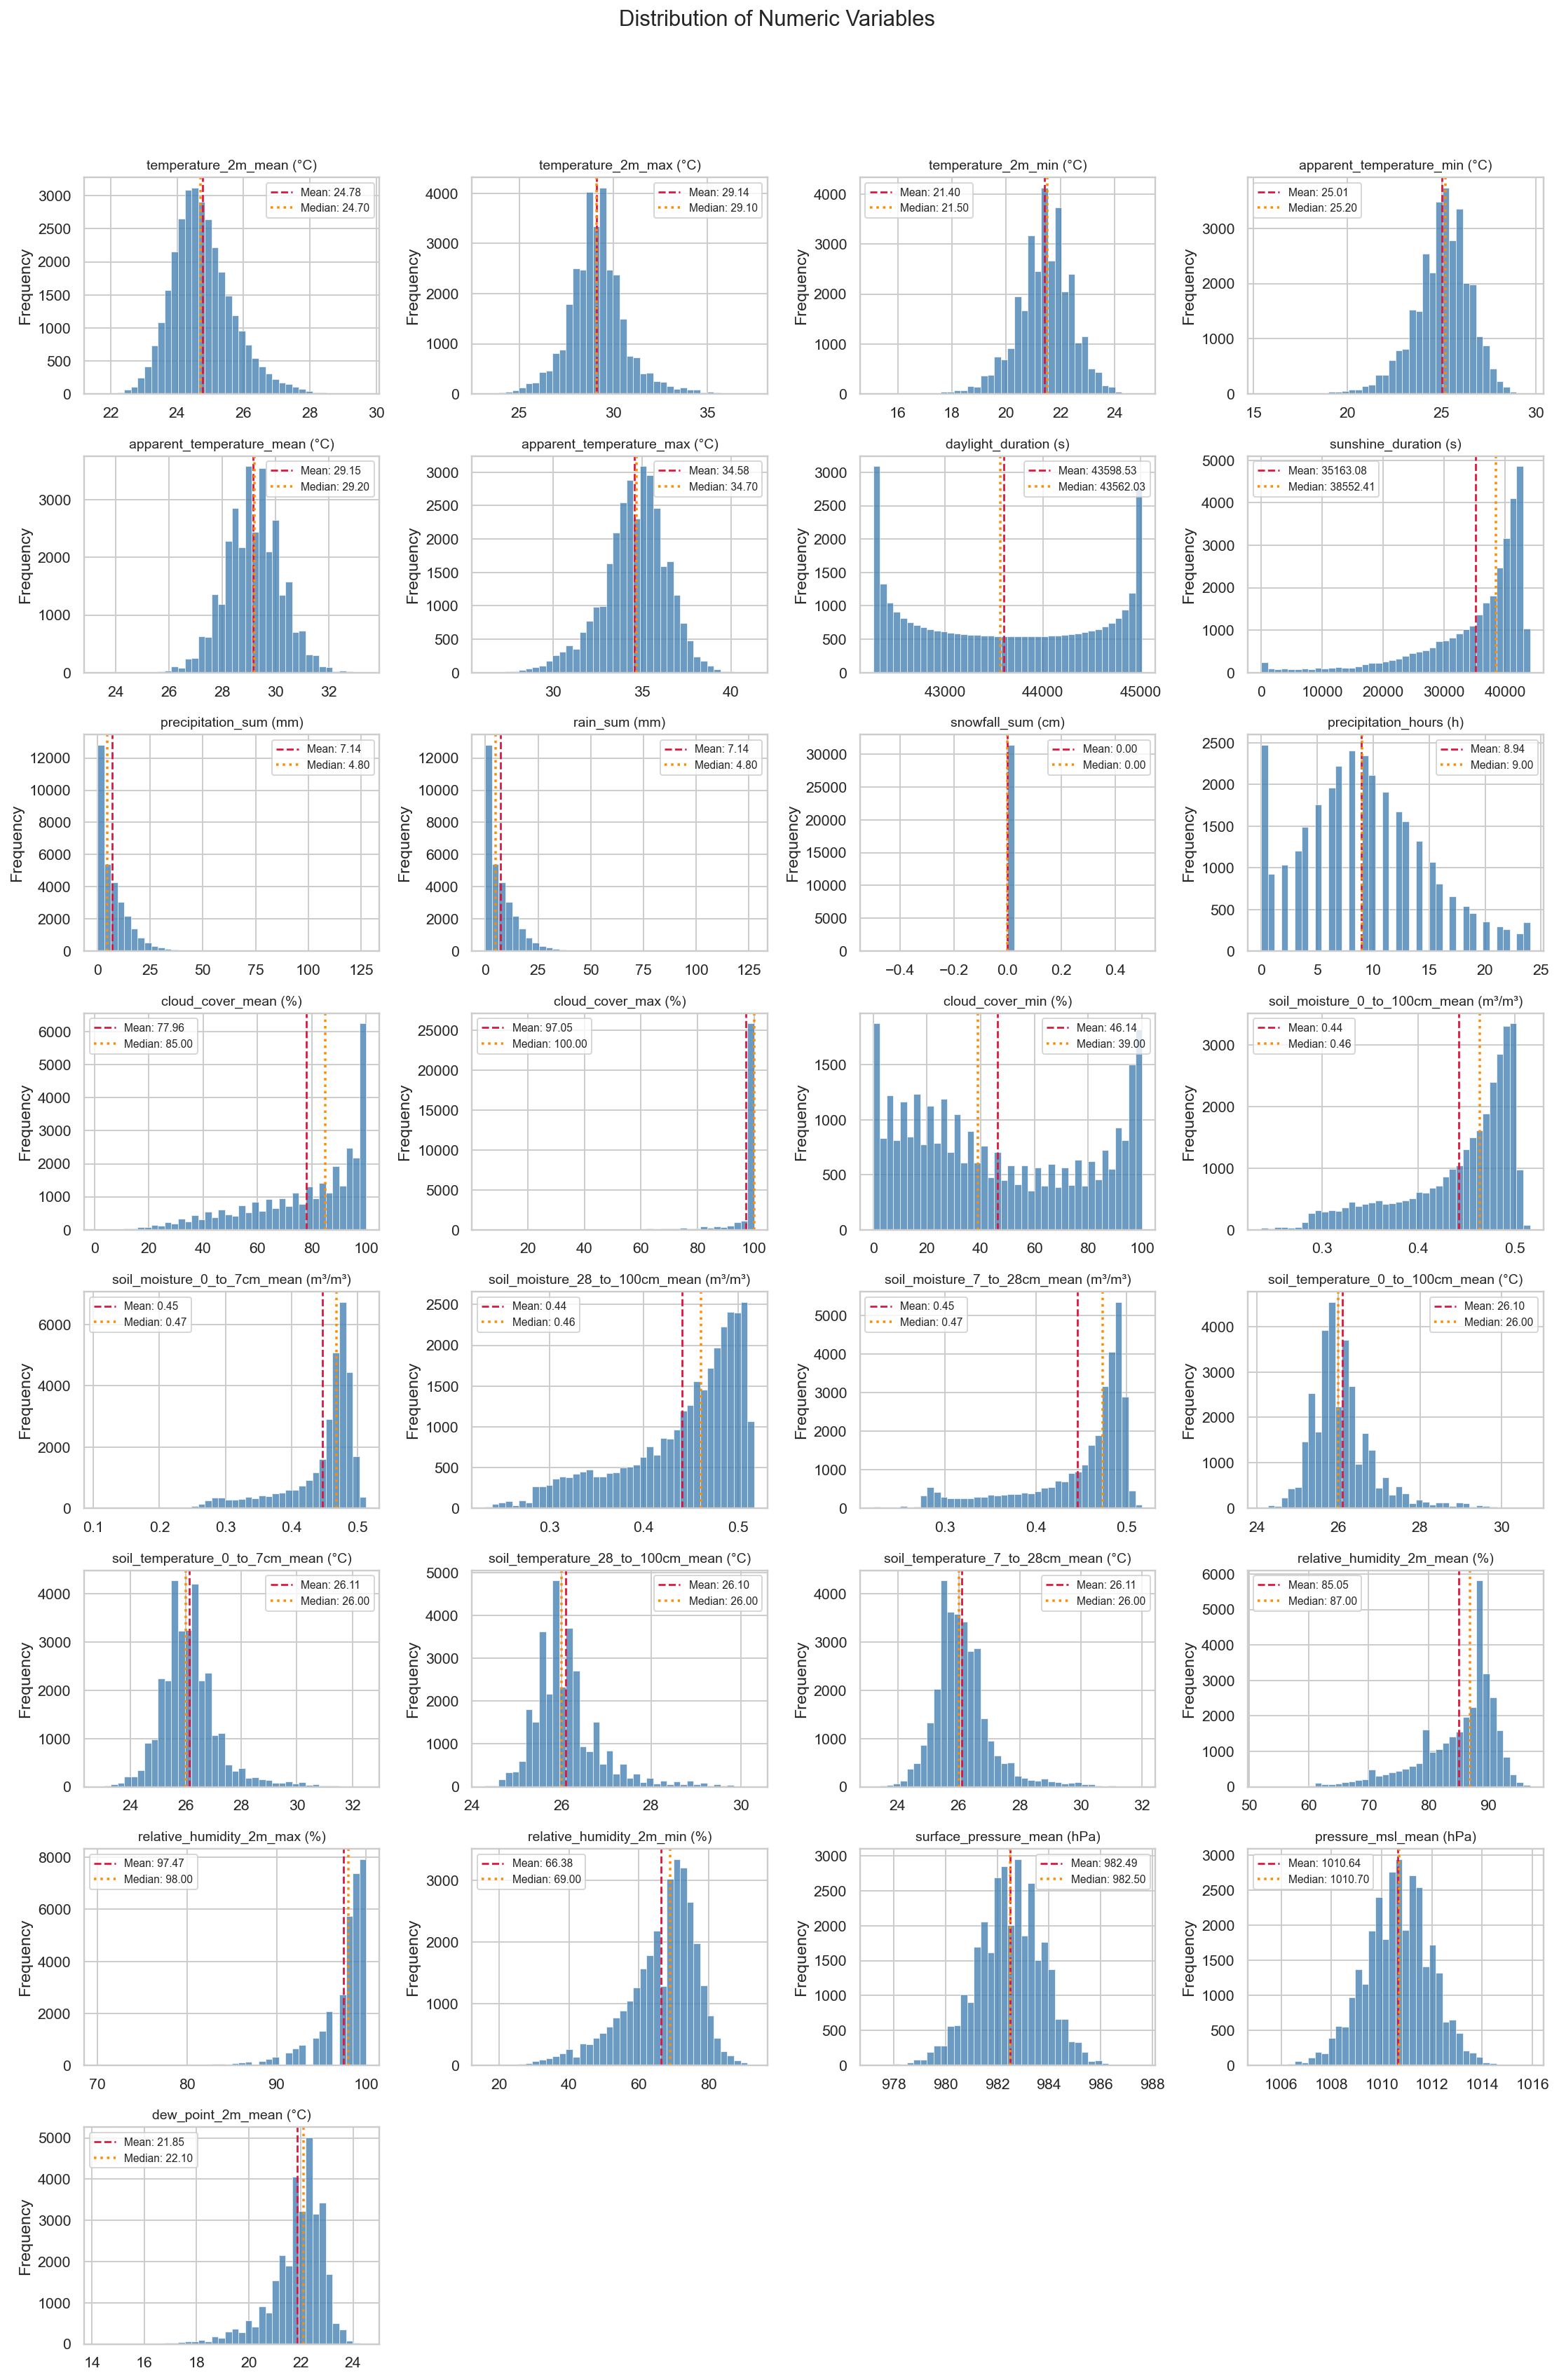

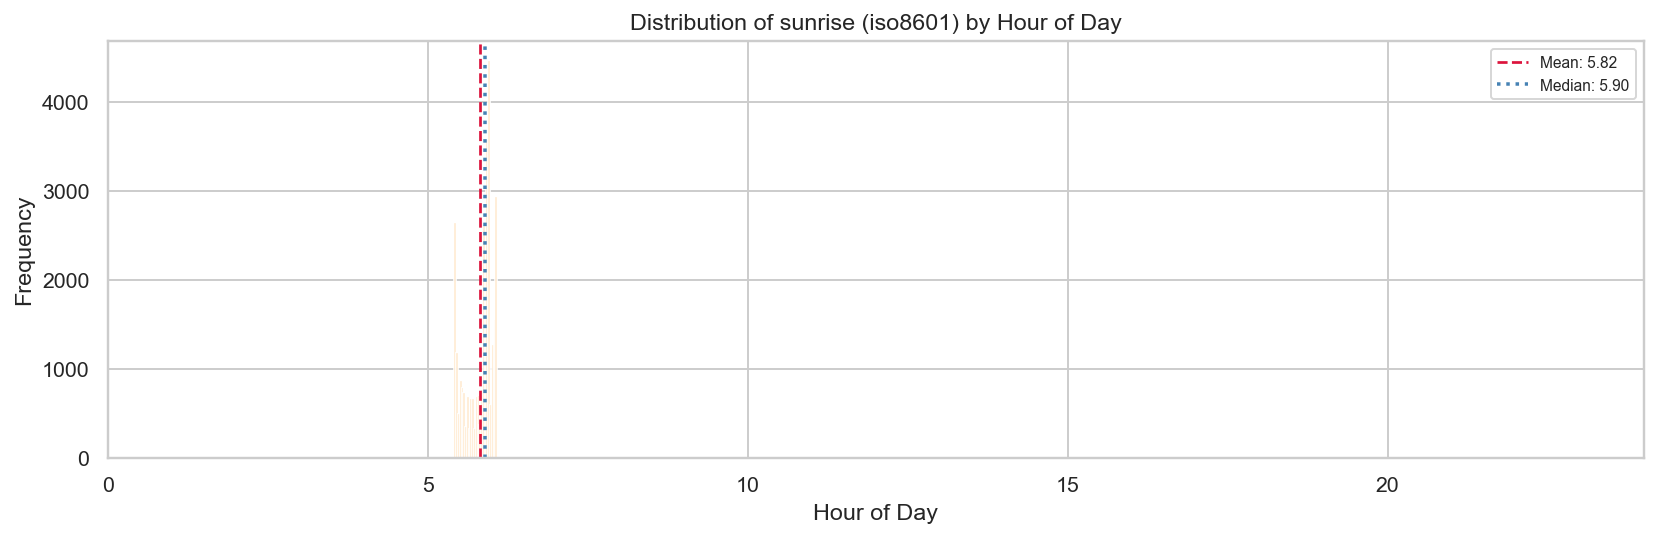

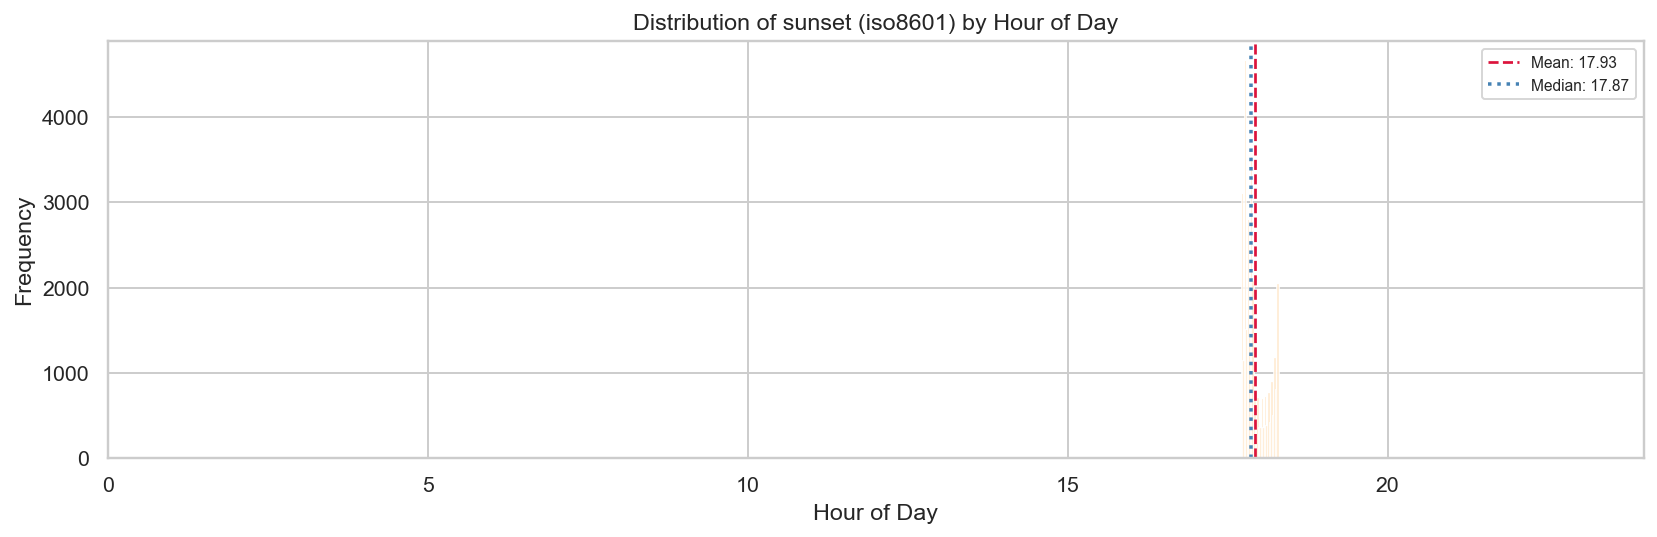

In [86]:
# Plot distributions for all variables by data type
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
datetime_cols = [column for column in df.columns if pd.api.types.is_datetime64_any_dtype(df[column])]
categorical_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()

for column in categorical_cols:
    order = df[column].value_counts().index

    fig, ax = plt.subplots(figsize=(14, max(5, 0.45 * len(order) + 2)))
    sns.countplot(data=df, y=column, order=order, ax=ax, color='seagreen')
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    fig.tight_layout()
    plt.show()

if numeric_cols:
    cols_per_row = 4
    n_rows = int(np.ceil(len(numeric_cols) / cols_per_row))
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 4, n_rows * 3))
    axes = np.atleast_1d(axes).ravel()

    for ax, column in zip(axes, numeric_cols):
        values = df[column].dropna()
        mean_value = values.mean()
        median_value = values.median()

        ax.hist(values, bins=40, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.4)
        ax.axvline(mean_value, color='crimson', linestyle='--', linewidth=1.4, label=f'Mean: {mean_value:.2f}')
        ax.axvline(median_value, color='darkorange', linestyle=':', linewidth=1.8, label=f'Median: {median_value:.2f}')
        ax.set_title(column, fontsize=10)
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)

    for ax in axes[len(numeric_cols):]:
        ax.axis('off')

    fig.suptitle('Distribution of Numeric Variables', fontsize=16, y=1.01)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

for column in datetime_cols:
    values = df[column].dropna()
    hour_values = values.dt.hour + values.dt.minute / 60
    mean_value = hour_values.mean()
    median_value = hour_values.median()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.hist(hour_values, bins=24, color='darkorange', alpha=0.85, edgecolor='white')
    ax.axvline(mean_value, color='crimson', linestyle='--', linewidth=1.4, label=f'Mean: {mean_value:.2f}')
    ax.axvline(median_value, color='steelblue', linestyle=':', linewidth=1.8, label=f'Median: {median_value:.2f}')
    ax.set_title(f'Distribution of {column} by Hour of Day')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Frequency')
    ax.set_xlim(0, 24)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
